# **Unsupervised Learning: Clustering Analysis**

## **Data Preparation and The "Blind" Strategy**
Unlike Classification or Regression tasks, Clustering is strictly unsupervised. The objective is to discover natural mathematical groupings (clusters) among patients based solely on their clinical and demographic similarities. To achieve this, we must completely remove the target variables (`diagnosed_diabetes`, `diabetes_stage`, `diabetes_risk_score`) to prevent the algorithm from "cheating". 

Furthermore, distance-based algorithms like K-Means rely heavily on Euclidean geometry. If left unscaled, features with large magnitudes (e.g., glucose levels) will distort the geometric space and overpower categorical variables. Therefore, **Standardization (`StandardScaler`) is strictly mandatory**.

## **Defeating the Curse of Dimensionality (PCA)**
High-dimensional datasets suffer from the "Curse of Dimensionality", where the geometric distance between any two points approaches uniformity, making clustering algorithms highly inefficient. To solve this, we will pass our standardized dataset through a **Principal Component Analysis (PCA via SVD)**, extracting only the components necessary to retain 95% of the cumulative variance. This compresses our data into a dense, highly informative matrix, optimizing the K-Means distance calculations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Data
df = pd.read_csv("C:\\Users\\Tiago Silva\\Uni\\OneDrive - Universidade Portucalense\\Ambiente de Trabalho\\Uni\\3ano2sem\\LAD\\Grupo5_ProjetoLAD_Parte2\\TrabalhoLAD\\data\\diabetes_dataset_new_variables.csv")

# One-Hot Encoding
categorical_cols = ['gender', 'ethnicity', 'smoking_status', 'education_level', 'employment_status', 'age_groups', 'weight_status', 'income_level']
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop ALL target variables for Unsupervised Learning
X_unsupervised = df_final.drop(["diagnosed_diabetes", "diabetes_stage", "diabetes_risk_score"], axis=1, errors='ignore')

# Mandatory Scaling (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

# Apply PCA (95% Variance) to combat the Curse of Dimensionality
pca_clustering = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_pca = pca_clustering.fit_transform(X_scaled)

n_components = pca_clustering.n_components_
print(f"Original Features: {X_unsupervised.shape[1]}")
print(f"PCA reduced the space to {n_components} components while retaining 95% of the variance.")

Original Features: 53
PCA reduced the space to 36 components while retaining 95% of the variance.


## **Determining the Optimal K: The Elbow Method**
Before running our final K-Means algorithm, we must mathematically determine the optimal number of patient clusters ($K$). We will test values of $K$ from 2 to 10 and record the **Inertia** (Within-Cluster Sum of Squares). The goal is to find the "elbow" point in the graph — the exact point where adding more clusters yields diminishing returns in variance reduction.

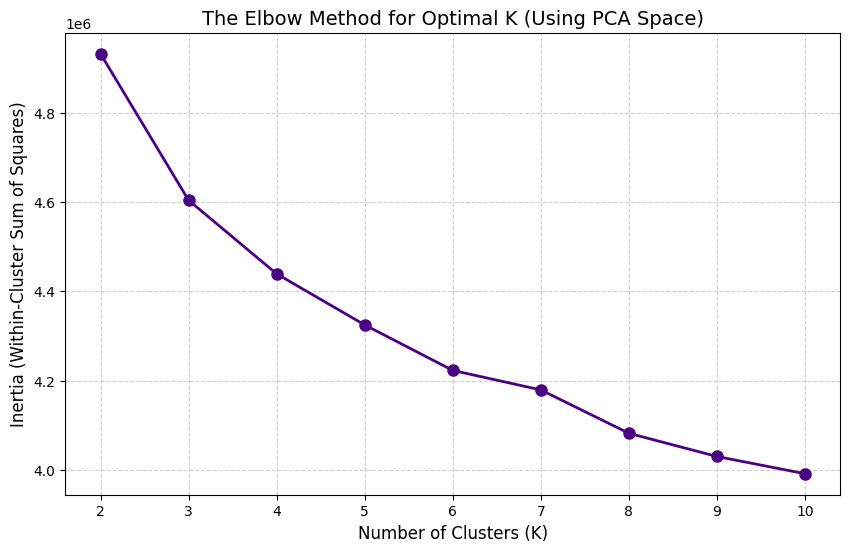

In [2]:
from sklearn.cluster import KMeans

# Calculate Inertia for different values of K
K_range = range(2, 11)
inertia_values = []

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X_pca)
    inertia_values.append(kmeans_temp.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_values, marker='o', linestyle='-', color='indigo', linewidth=2, markersize=8)
plt.title('The Elbow Method for Optimal K (Using PCA Space)', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Final K-Means Execution (Elbow Graph Interpretation)**

Based on our mathematical analysis of the Elbow Method graph, we observe the Inertia (Within-Cluster Sum of Squares) consistently decreasing as the number of clusters ($K$) increases. The initial drops from $K=2$ to $K=3$ and from $K=3$ to $K=4$ are steep and highly pronounced. This indicates that adding these specific clusters captures a massive amount of hidden variance and significantly improves the geometric grouping of the patients. 

However, exactly at **$K=4$**, the curve forms a distinct "elbow" and begins to flatten into a much slower, almost linear descent. Adding a 5th or 6th cluster yields rapidly diminishing returns in variance reduction, while simultaneously risking the over-complication of the clinical profiles (creating groups that are too small or practically indistinguishable for medical analysis). 

Because $K=4$ represents the perfect equilibrium between mathematical precision and clinical interpretability, we will segment our patient population into **4 distinct clinical profiles**. We will fit the final K-Means algorithm using the compressed PCA feature space and map these cluster labels back to our dataset for future clinical profiling.

In [3]:
# Define the chosen optimal K
OPTIMAL_K = 4

# Train the final K-Means model
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_pca)

# Add the group "labels" to the original dataset (for analysis)
df_clustered = df_final.copy()
df_clustered['Cluster_Profile'] = cluster_labels

# Show the size of each patient group
print(f"--- K-MEANS CLUSTERING RESULTS (K={OPTIMAL_K}) ---")
cluster_counts = df_clustered['Cluster_Profile'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} patients ({(count/len(df_clustered))*100:.1f}%)")

--- K-MEANS CLUSTERING RESULTS (K=4) ---
Cluster 0: 2457 patients (2.5%)
Cluster 1: 43135 patients (43.1%)
Cluster 2: 11301 patients (11.3%)
Cluster 3: 43107 patients (43.1%)


### **K-Means Population Distribution Analysis**

The execution of the K-Means algorithm (with $K=4$) reveals a highly asymmetrical distribution of the patient population, which is a common and expected phenomenon in real-world healthcare datasets:

* **The Majority Profiles (Clusters 1 & 3):** Together, these two clusters account for approximately 86.2% of the total dataset. This suggests they represent the most common demographic and clinical baselines (e.g., standard healthy individuals or typical low-risk patients).
* **The Minority Profile (Cluster 2):** Capturing 11.3% of the population, this group likely represents a specific sub-population with distinct risk factors or demographic traits that separate them from the general majority.
* **The Extreme/Niche Profile (Cluster 0):** Containing only 2.5% of the patients, this highly isolated cluster mathematically represents extreme deviations from the mean. Clinically, this could correspond to acute outliers, patients with severe compounding conditions, or very rare demographic combinations.

## **Hierarchical Clustering Validation (Dendrogram)**
While K-Means is highly efficient for 100,000 rows, it requires us to pre-define $K$. To scientifically validate our choice of $K=4$, we employ an alternative unsupervised approach: **Agglomerative Hierarchical Clustering**. 

Because computing a hierarchical distance matrix for 100,000 patients requires thousands of gigabytes of RAM (an $O(N^2)$ memory complexity), executing this on the full dataset will cause a hardware crash. To overcome this computational bottleneck while maintaining statistical validity, we take a **representative random sample of 2,000 patients**. We construct a Dendrogram using Ward's linkage (which minimizes the variance of merged clusters, identical to the K-Means objective function) to visually confirm the natural mathematical groupings.

**Methodological Note (Two-Step Execution):** In practice, this visual validation is performed in two sequential stages. First, we generate a preliminary dendrogram to explore the hierarchy and visually identify the largest vertical gaps between cluster merges. Once the optimal Euclidean distance threshold is discovered, we execute the plot a second time, injecting a definitive horizontal cut line ($y=64$) to explicitly demonstrate that it intersects exactly 4 major branches, perfectly corroborating our K-Means configuration.

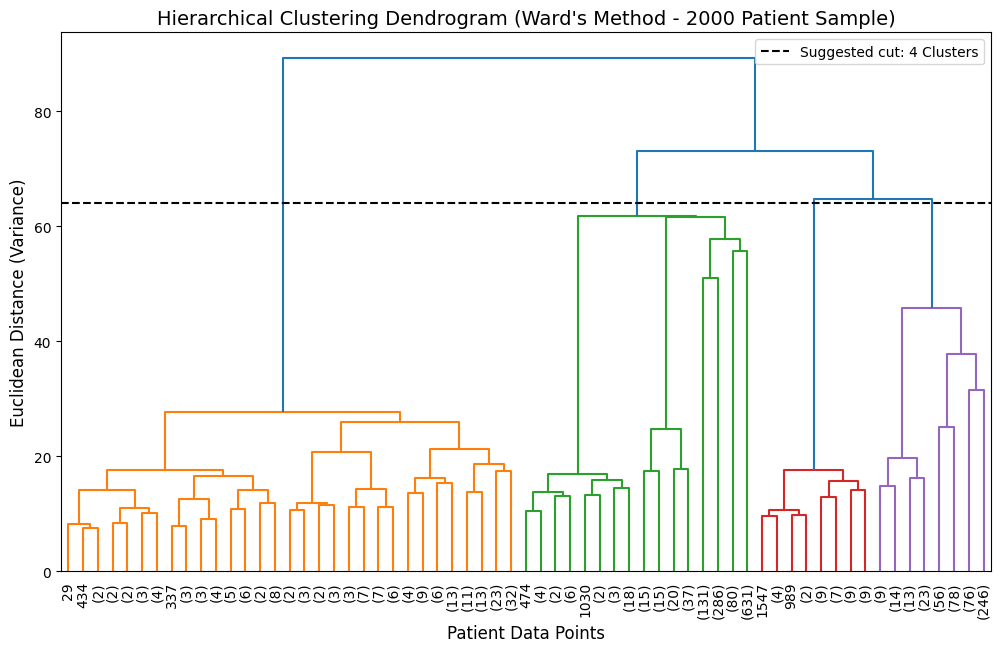

Clustering Unsupervised Pipeline Completed Successfully!


In [10]:
import scipy.cluster.hierarchy as shc

# Strategic sample extraction
np.random.seed(42)
sample_indices = np.random.choice(X_pca.shape[0], size=2000, replace=False)
X_pca_sample = X_pca[sample_indices]

# Draw the dendrogram
plt.figure(figsize=(12, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward's Method - 2000 Patient Sample)", fontsize=14)
plt.xlabel("Patient Data Points", fontsize=12)
plt.ylabel("Euclidean Distance (Variance)", fontsize=12)

# The 'ward' method minimizes within-cluster variance, just like K-Means
dendrogram = shc.dendrogram(
    shc.linkage(X_pca_sample, method='ward'),
    truncate_mode='level', # Simplifies the visualization by hiding the lower levels
    p=5,                   # Shows only the last 5 major merges
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=10.
)

plt.axhline(y=64, color='black', linestyle='--', label='Suggested cut: 4 Clusters')
plt.legend()

plt.show()

print("Clustering Unsupervised Pipeline Completed Successfully!")

### **Hierarchical Clustering Validation Analysis**

The Agglomerative Hierarchical Clustering (using Ward's method to minimize intra-cluster variance) visually corroborates the mathematical findings of the K-Means Elbow Method:

1. **Distance and Merges:** The Y-axis represents the Euclidean distance between patient profiles. The highest vertical links indicate massive clinical differences between the macro-groups.
2. **The Optimal Cut ($K=4$):** By introducing a horizontal threshold cut at a Euclidean distance of approximately `y=64`, we intersect exactly four distinct vertical branches. 
3. **Natural Groupings:** The algorithm naturally highlights these 4 foundational sub-populations (visually separated into distinct colored branches). This proves that segmenting our dataset into 4 clusters ($K=4$) is not an arbitrary choice, but rather the most geometrically stable configuration to categorize diabetes patient profiles before the macro-groups become too generalized at higher distances.